In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rankdata
from utils import load_g09
import pyvinecopulib as pv

In [3]:
g09 = load_g09()

/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inp

In [4]:
sel = (g09['g-i'] > 0.) * (g09['g-i'] < 2) * (g09['mag_Zt'] < 21.1)


In [5]:
g09_valid = g09[sel]
g09_valid = g09_valid[g09_valid['z_paus'] < 0.2]

g09_valid = g09_valid.dropna(subset=['P020_comb', 'g-i', 'z_paus', 'mag_Zt'])
g09_fn = g09_valid[g09_valid['P020_comb'] < 0.14]


g09_valid['TP'] = g09_valid['P020_comb'] > 0.14
g09_valid['FN'] = g09_valid['P020_comb'] < 0.14

In [6]:
pi_fp = len(g09_fn)/ len(g09_valid)

In [7]:
pi_fp

0.05065077622706602

Text(0, 0.5, 'Count')

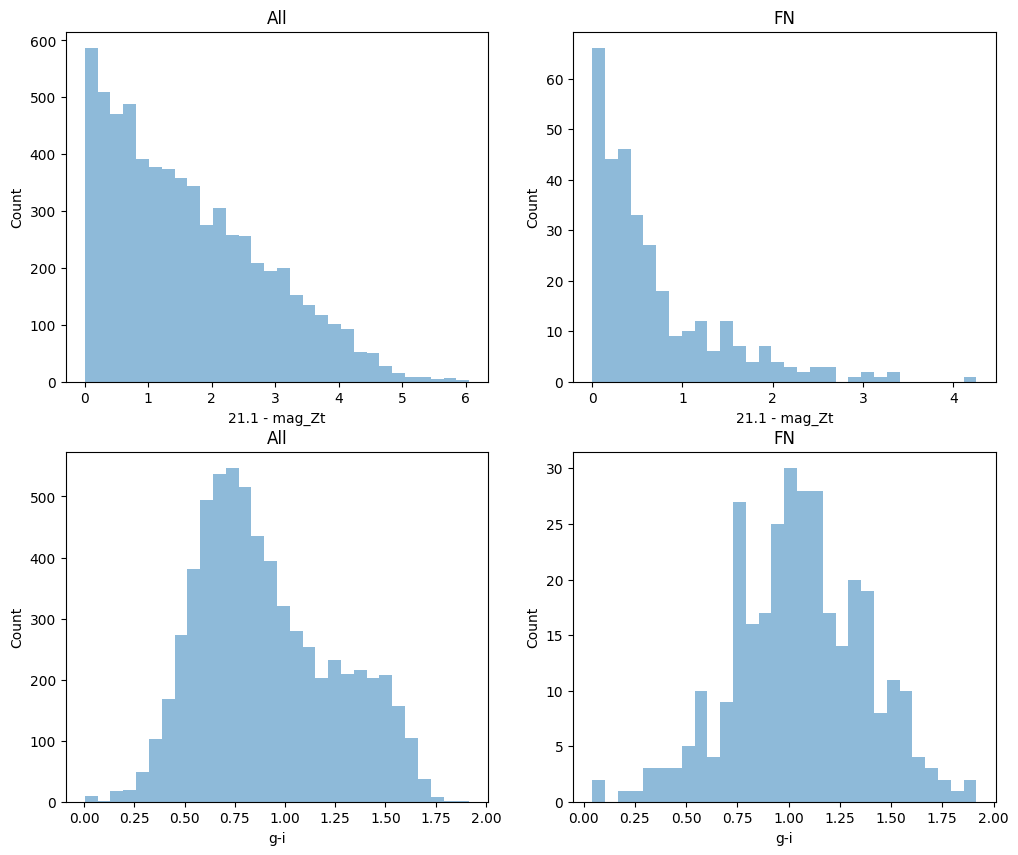

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))


axs[0, 0].hist(-g09_valid['mag_Zt'] + 21.1, bins=30, alpha=0.5, label='All')
axs[0, 0].set_title('All')
axs[0,0].set_xlabel('21.1 - mag_Zt')
axs[0,0].set_ylabel('Count')
# density linearly decreasing from 0 to 5, then fix to 0?

axs[0, 1].hist(-g09_fn['mag_Zt'] + 21.1, bins=30, alpha=0.5)
axs[0, 1].set_title('FN')
axs[0,1].set_xlabel('21.1 - mag_Zt')
axs[0,1].set_ylabel('Count')
# density modelled by a beta function 

axs[1, 0].hist(g09_valid['g-i'], bins=30, alpha=0.5, label='All')
axs[1, 0].set_title('All')
axs[1,0].set_xlabel('g-i')
axs[1,0].set_ylabel('Count')
# density modelled by a double gaussian 

axs[1, 1].hist(g09_fn['g-i'], bins=30, alpha=0.5)
axs[1, 1].set_title('FN')
axs[1,1].set_xlabel('g-i')
axs[1,1].set_ylabel('Count')
# density modelled by a single gaussian

In [9]:
xy_all = np.column_stack([-g09_valid['mag_Zt'] + 21.1, g09_valid['g-i']])
xy_fn = np.column_stack([-g09_fn['mag_Zt'] + 21.1, g09_fn['g-i']])
xy_all_tp = g09_valid['TP'].to_numpy()
xy_all_fn = g09_valid['FN'].to_numpy()

mag_fn  w=0.481  linear(-0.841x+0.747)  N(0.900,0.941)
gi_all  w=0.695  N(0.727,0.207)  N(1.335,0.223)
gi_fn   N(1.056, 0.322)


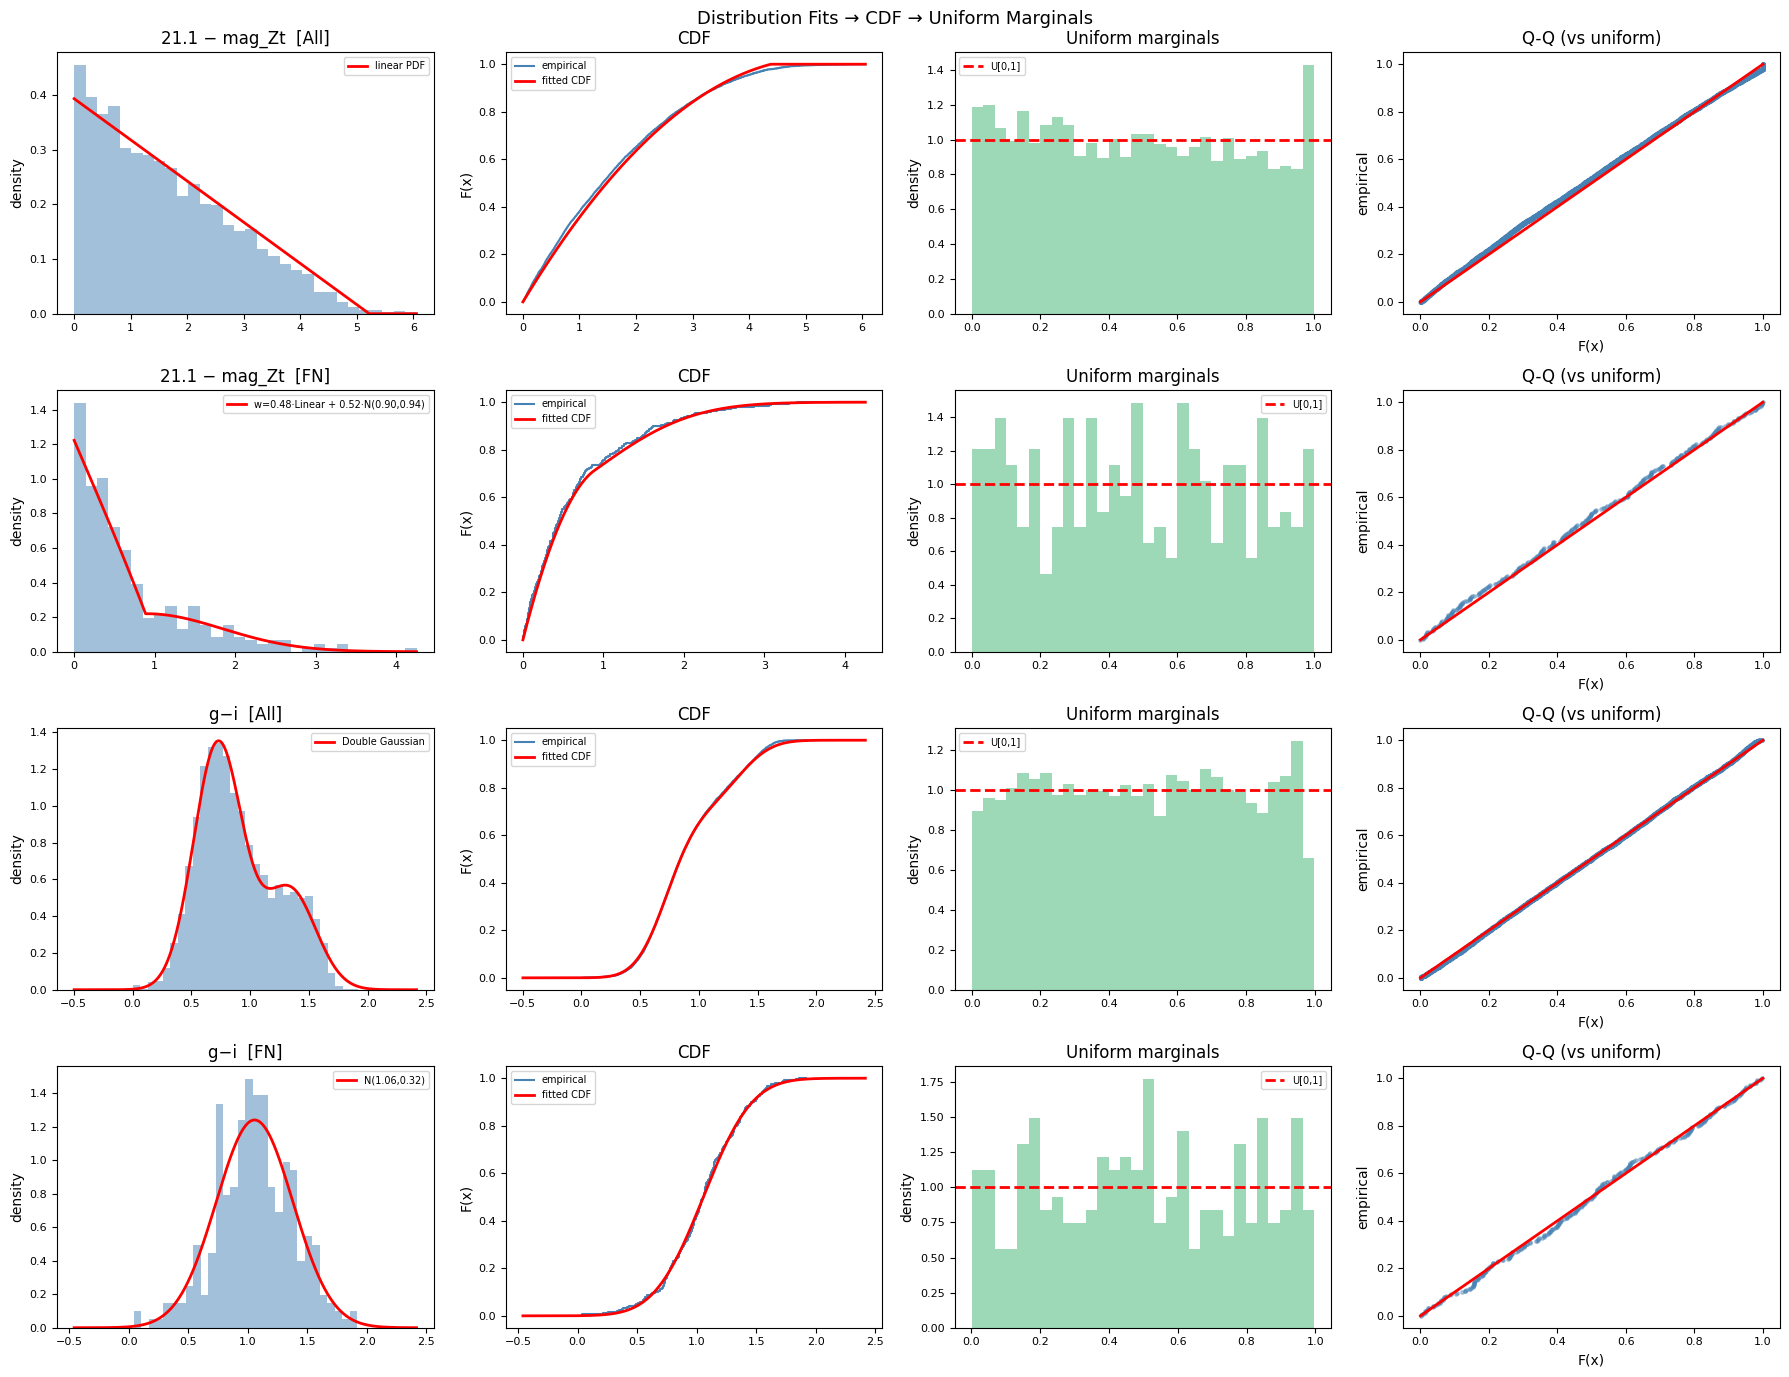

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
from scipy.integrate import cumulative_trapezoid

# ── Helper: numerical CDF from a PDF array ────────────────────────────────────
def pdf_to_cdf(xr, pdf_vals):
    cdf = cumulative_trapezoid(pdf_vals, xr, initial=0)
    cdf /= cdf[-1]
    return cdf

def cdf_transform(data, xr, cdf_vals):
    return np.interp(data, xr, cdf_vals)

# ════════════════════════════════════════════════════════════════════════════════
# YOUR DATA
# ════════════════════════════════════════════════════════════════════════════════
mag_all = -g09_valid['mag_Zt'] + 21.1   # linear-decreasing, support [0, ~5]
mag_fn  = -g09_fn['mag_Zt']   + 21.1   # same transform, FN subset
gi_all  = g09_valid['g-i']             # double gaussian
gi_fn   = g09_fn['g-i']                # single gaussian


# ════════════════════════════════════════════════════════════════════════════════
# 1.  mag_all  →  LINEAR (decreasing) PDF  f(x) = mx + c, support [0, x_max]
# ════════════════════════════════════════════════════════════════════════════════
counts, edges = np.histogram(mag_all, bins=30, density=True)
bc = (edges[:-1] + edges[1:]) / 2
slope_m, intercept_m, *_ = stats.linregress(bc, counts)

x_min_m, x_max_m = mag_all.min(), mag_all.max()
C_m = -(0.5 * slope_m * x_min_m**2 + intercept_m * x_min_m)

def lin_pdf(x): return np.clip(slope_m * x + intercept_m, 0, None)
def lin_cdf(x): return np.clip(0.5 * slope_m * x**2 + intercept_m * x + C_m, 0, 1)

u_mag_all = lin_cdf(mag_all)


# ════════════════════════════════════════════════════════════════════════════════
# 2.  mag_fn  →  LINEAR + GAUSSIAN mixture
# ════════════════════════════════════════════════════════════════════════════════
def linear_gauss(x, w, slope, intercept, mu, sigma):
    linear = np.clip(slope * x + intercept, 0, None)
    norm_factor = np.trapezoid(linear, x)
    if norm_factor > 0:
        linear /= norm_factor
    gauss = stats.norm.pdf(x, mu, sigma)
    return w * linear + (1 - w) * gauss

counts_fn, edges_fn = np.histogram(mag_fn, bins=30, density=True)
bc_fn = (edges_fn[:-1] + edges_fn[1:]) / 2

p0 = [0.5, -0.1, 1.0, mag_fn.mean(), mag_fn.std()]
bounds = ([0,  -10, -10,  mag_fn.min(), 0.01],
          [1,   10,  10,  mag_fn.max(), 10  ])
popt_fn, _ = curve_fit(linear_gauss, bc_fn, counts_fn, p0=p0,
                        bounds=bounds, maxfev=20000)
w_fn, slope_fn, intercept_fn, mu_fn, sigma_fn = popt_fn
print(f"mag_fn  w={w_fn:.3f}  linear({slope_fn:.3f}x+{intercept_fn:.3f})  N({mu_fn:.3f},{sigma_fn:.3f})")

xr_fn = np.linspace(mag_fn.min(), mag_fn.max(), 2000)
pdf_fn = linear_gauss(xr_fn, *popt_fn)
cdf_fn = pdf_to_cdf(xr_fn, pdf_fn)
u_mag_fn = cdf_transform(mag_fn, xr_fn, cdf_fn)


# ════════════════════════════════════════════════════════════════════════════════
# 3.  gi_all  →  DOUBLE GAUSSIAN mixture
# ════════════════════════════════════════════════════════════════════════════════
def double_gauss(x, w, mu1, s1, mu2, s2):
    return (w * stats.norm.pdf(x, mu1, s1) +
            (1-w) * stats.norm.pdf(x, mu2, s2))

counts_gi, edges_gi = np.histogram(gi_all, bins=30, density=True)
bc_gi = (edges_gi[:-1] + edges_gi[1:]) / 2

# initial guess: eyeball two peaks from your histogram
p0 = [0.5, gi_all.mean()-0.5, gi_all.std()*0.5,
           gi_all.mean()+0.5, gi_all.std()*0.5]
bounds = ([0,  -10, 0.01, -10, 0.01],
          [1,   10,    5,  10,    5])
popt_gi, _ = curve_fit(double_gauss, bc_gi, counts_gi, p0=p0,
                        bounds=bounds, maxfev=20000)
w_gi, mu1_gi, s1_gi, mu2_gi, s2_gi = popt_gi
print(f"gi_all  w={w_gi:.3f}  N({mu1_gi:.3f},{s1_gi:.3f})  N({mu2_gi:.3f},{s2_gi:.3f})")

xr_gi = np.linspace(gi_all.min()-0.5, gi_all.max()+0.5, 2000)
pdf_gi = double_gauss(xr_gi, *popt_gi)
cdf_gi = pdf_to_cdf(xr_gi, pdf_gi)
u_gi_all = cdf_transform(gi_all, xr_gi, cdf_gi)


# ════════════════════════════════════════════════════════════════════════════════
# 4.  gi_fn  →  SINGLE GAUSSIAN
# ════════════════════════════════════════════════════════════════════════════════
mu_fn_gi, sigma_fn_gi = stats.norm.fit(gi_fn)
print(f"gi_fn   N({mu_fn_gi:.3f}, {sigma_fn_gi:.3f})")

xr_gi_fn = np.linspace(gi_fn.min()-0.5, gi_fn.max()+0.5, 2000)
pdf_gi_fn = stats.norm.pdf(xr_gi_fn, mu_fn_gi, sigma_fn_gi)
cdf_gi_fn = pdf_to_cdf(xr_gi_fn, pdf_gi_fn)
u_gi_fn = cdf_transform(gi_fn, xr_gi_fn, cdf_gi_fn)




# ════════════════════════════════════════════════════════════════════════════════
# PLOTS  (2 rows × 4 cols:  col1=fit, col2=CDF, col3=uniform marginals, col4=Q-Q)
# ════════════════════════════════════════════════════════════════════════════════
fig, axs = plt.subplots(4, 4, figsize=(18, 14))
fig.suptitle("Distribution Fits → CDF → Uniform Marginals", fontsize=13)

datasets = [
    ("21.1 − mag_Zt  [All]",  mag_all,   lin_pdf(np.linspace(x_min_m, x_max_m, 300)),
     np.linspace(x_min_m, x_max_m, 300),
     lin_cdf(np.linspace(x_min_m, x_max_m, 300)), u_mag_all, "linear PDF"),

    ("21.1 − mag_Zt  [FN]", mag_fn, linear_gauss(xr_fn, *popt_fn),
    xr_fn, cdf_fn, u_mag_fn, f"w={w_fn:.2f}·Linear + {1-w_fn:.2f}·N({mu_fn:.2f},{sigma_fn:.2f})"),

    ("g−i  [All]",            gi_all,    double_gauss(xr_gi, *popt_gi),
     xr_gi, cdf_gi, u_gi_all, f"Double Gaussian"),

    ("g−i  [FN]",             gi_fn,     stats.norm.pdf(xr_gi_fn, mu_fn_gi, sigma_fn_gi),
     xr_gi_fn, cdf_gi_fn, u_gi_fn, f"N({mu_fn_gi:.2f},{sigma_fn_gi:.2f})"),
]

for row, (title, data, pdf_r, xr, cdf_r, u, fit_label) in enumerate(datasets):
    # col 0: data + fit
    axs[row, 0].hist(data, bins=30, density=True, alpha=0.5, color="steelblue")
    axs[row, 0].plot(xr, pdf_r, "r-", lw=2, label=fit_label)
    axs[row, 0].set(title=title, ylabel="density")
    axs[row, 0].legend(fontsize=7)

    # col 1: empirical vs fitted CDF
    xs = np.sort(data)
    axs[row, 1].step(xs, np.arange(1, len(data)+1)/len(data),
                     color="steelblue", lw=1.5, label="empirical")
    axs[row, 1].plot(xr, cdf_r, "r-", lw=2, label="fitted CDF")
    axs[row, 1].set(title="CDF", ylabel="F(x)")
    axs[row, 1].legend(fontsize=7)

    # col 2: uniform marginals
    axs[row, 2].hist(u, bins=30, density=True, alpha=0.5, color="mediumseagreen")
    axs[row, 2].axhline(1.0, color="r", lw=2, ls="--", label="U[0,1]")
    axs[row, 2].set(title="Uniform marginals", ylabel="density")
    axs[row, 2].legend(fontsize=7)

    # col 3: Q-Q vs uniform
    axs[row, 3].scatter(np.sort(u), np.linspace(0, 1, len(u)),
                        s=6, alpha=0.4, color="steelblue")
    axs[row, 3].plot([0, 1], [0, 1], "r-", lw=2)
    axs[row, 3].set(title="Q-Q (vs uniform)", xlabel="F(x)", ylabel="empirical")

for ax in axs.flat:
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig("all_fits_marginals.png", dpi=150)
plt.show()

In [11]:
u_mag_all = u_mag_all.to_numpy()

In [12]:
uv_all = np.column_stack((u_mag_all, u_gi_all))
uv_fn = np.column_stack((u_mag_fn, u_gi_fn))

Text(0.5, 1.0, 'Uniform Marginals: u_mag vs u_gi')

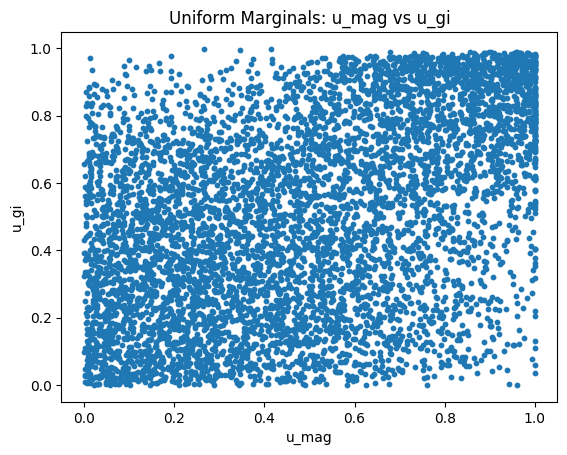

In [13]:
plt.scatter(uv_all[:, 0], uv_all[:, 1], s=10, label='All')
plt.xlabel('u_mag')
plt.ylabel('u_gi')
plt.title('Uniform Marginals: u_mag vs u_gi')

Text(0.5, 1.0, 'Uniform Marginals: u_mag vs u_gi')

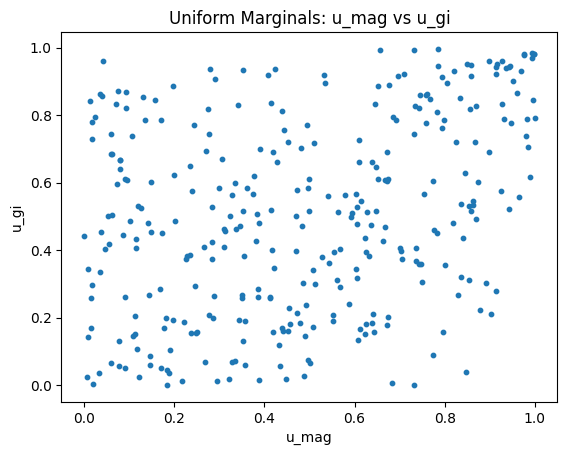

In [14]:
plt.scatter(uv_fn[:, 0], uv_fn[:, 1], s=10, label='All')
plt.xlabel('u_mag')
plt.ylabel('u_gi')
plt.title('Uniform Marginals: u_mag vs u_gi')

In [15]:
controls = pv.FitControlsBicop(family_set=pv.parametric)
cop_all = pv.Bicop.from_data(data=uv_all, controls=controls)
cop_fn = pv.Bicop.from_data(data=uv_fn, controls=controls)


In [16]:
print(cop_all, cop_fn)

<pyvinecopulib.Bicop> Bivariate copula: 
  family = BB8
  rotation = 0
  var_types = c,c
  parameters =  2.8
0.77
 <pyvinecopulib.Bicop> Bivariate copula: 
  family = BB8
  rotation = 0
  var_types = c,c
  parameters =  1.6
0.98



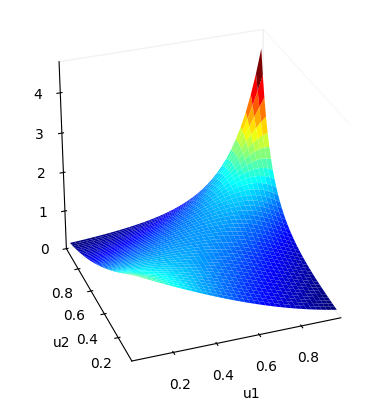

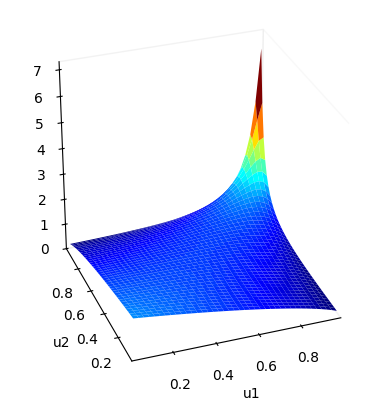

In [17]:
cop_all.plot()
cop_fn.plot()

In [18]:
samples_all = cop_all.simulate(6000)
samples_fn = cop_fn.simulate(300)

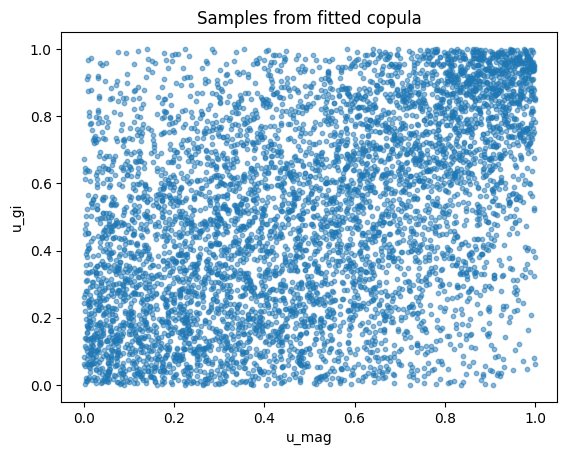

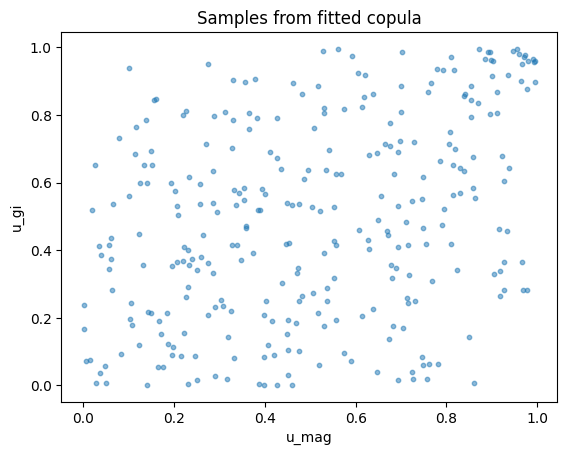

In [19]:
plt.scatter(samples_all[:, 0], samples_all[:, 1], s=10, alpha=0.5, label='All')
plt.xlabel('u_mag')
plt.ylabel('u_gi')
plt.title('Samples from fitted copula')
plt.show()
plt.scatter(samples_fn[:, 0], samples_fn[:, 1], s=10, alpha=0.5, label='FN')
plt.xlabel('u_mag')
plt.ylabel('u_gi')
plt.title('Samples from fitted copula')
plt.show()

In [360]:
# ── Helper: numerical inverse CDF (works for any numerically-defined CDF) ─────
def inverse_cdf_numerical(u, xr, cdf_vals):
    """Map u in [0,1] back to x via interpolation of the numerical CDF."""
    return np.interp(u, cdf_vals, xr)


# ════════════════════════════════════════════════════════════════════════════════
# 1.  mag_all  →  LINEAR  (analytic inverse)
#     F(x) = 0.5*slope*x^2 + intercept*x + C  →  invert via quadratic formula
# ════════════════════════════════════════════════════════════════════════════════
def inv_linear_cdf(u):
    """Inverse of F(x) = 0.5*m*x^2 + c*x + C.  Solves quadratic for x."""
    # 0.5*m*x^2 + c*x + (C - u) = 0
    a_coef = 0.5 * slope_m
    b_coef = intercept_m
    c_coef = C_m - u
    if abs(a_coef) < 1e-12:          # degenerate: nearly uniform, linear solve
        return np.clip(-c_coef / b_coef, x_min_m, x_max_m)
    discriminant = b_coef**2 - 4 * a_coef * c_coef
    discriminant = np.clip(discriminant, 0, None)
    x1 = (-b_coef + np.sqrt(discriminant)) / (2 * a_coef)
    x2 = (-b_coef - np.sqrt(discriminant)) / (2 * a_coef)
    # pick the root within the support
    candidates = np.where(
        (x1 >= x_min_m - 1e-6) & (x1 <= x_max_m + 1e-6), x1, x2
    )
    return np.clip(candidates, x_min_m, x_max_m)

def u_to_mag_all(u):
    return inv_linear_cdf(np.asarray(u))


# ════════════════════════════════════════════════════════════════════════════════
# 2.  mag_fn  →  LINEAR + GAUSSIAN  (numerical inverse)
# ════════════════════════════════════════════════════════════════════════════════
def u_to_mag_fn(u):
    """Inverse of the linear+gaussian mixture CDF via interpolation."""
    return inverse_cdf_numerical(np.asarray(u), xr_fn, cdf_fn)


# ════════════════════════════════════════════════════════════════════════════════
# 3.  gi_all  →  DOUBLE GAUSSIAN  (numerical inverse)
# ════════════════════════════════════════════════════════════════════════════════
def u_to_gi_all(u):
    return inverse_cdf_numerical(np.asarray(u), xr_gi, cdf_gi)


# ════════════════════════════════════════════════════════════════════════════════
# 4.  gi_fn  →  SINGLE GAUSSIAN  (analytic inverse = ppf)
# ════════════════════════════════════════════════════════════════════════════════
def u_to_gi_fn(u):
    return stats.norm.ppf(np.asarray(u), loc=mu_fn_gi, scale=sigma_fn_gi)


In [361]:
# ════════════════════════════════════════════════════════════════════════════════
# FORWARD TRANSFORM: real space → uniform [0,1]
# ════════════════════════════════════════════════════════════════════════════════

# ── Helper: numerical forward CDF ─────────────────────────────────────────────
def forward_cdf_numerical(x, xr, cdf_vals):
    """Map x in real space to u in [0,1] via interpolation of the numerical CDF."""
    return np.interp(np.asarray(x), xr, cdf_vals)


# 1.  mag_all  →  LINEAR  (analytic)
def mag_all_to_u(x):
    return lin_cdf(np.asarray(x))


# 2.  mag_fn  →  LINEAR + GAUSSIAN  (numerical)
def mag_fn_to_u(x):
    return forward_cdf_numerical(x, xr_fn, cdf_fn)


# 3.  gi_all  →  DOUBLE GAUSSIAN  (numerical)
def gi_all_to_u(x):
    return forward_cdf_numerical(x, xr_gi, cdf_gi)


# 4.  gi_fn  →  SINGLE GAUSSIAN  (analytic)
def gi_fn_to_u(x):
    return stats.norm.cdf(np.asarray(x), loc=mu_fn_gi, scale=sigma_fn_gi)

In [362]:
# ── Helper: numerical PDF via interpolation ───────────────────────────────────
def density_numerical(x, xr, pdf_vals):
    """Interpolate density at x from a precomputed PDF array."""
    return np.interp(np.asarray(x), xr, pdf_vals, left=0, right=0)


def density_real_mag_all(x):
    """Linear PDF for mag_all."""
    return lin_pdf(np.asarray(x))

def density_real_mag_fn(x):
    """Linear+Gaussian mixture PDF for mag_fn."""
    return density_numerical(x, xr_fn, linear_gauss(xr_fn, *popt_fn))

def density_real_gi_all(x):
    """Double Gaussian PDF for gi_all."""
    return density_numerical(x, xr_gi, double_gauss(xr_gi, *popt_gi))

def density_real_gi_fn(x):
    """Single Gaussian PDF for gi_fn."""
    return stats.norm.pdf(np.asarray(x), loc=mu_fn_gi, scale=sigma_fn_gi)

In [ ]:
def get_completeness(xy_input, copula_all, copula_fn, pi):
    """Compute completeness at xy_input by comparing PDFs from copula_all vs copula_fn.
    mag all and gi are input features, copula_all and copula_fn are the fitted copulas for the full vs FN (False Negative) subsets."""

    uv_input_all = mag_all_to_u(xy_input[:, 0]), gi_all_to_u(xy_input[:, 1])
    uv_input_fn = mag_fn_to_u(xy_input[:, 0]), gi_fn_to_u(xy_input[:, 1])

    

    uv_input_all = np.array(uv_input_all).T
    uv_input_fn = np.array(uv_input_fn).T

    u_all = copula_all.pdf(uv_input_all)
    u_fn = copula_fn.pdf(uv_input_fn)

    den_x_all = density_real_mag_all(xy_input[:, 0])
    den_x_fn = density_real_mag_fn(xy_input[:, 0])

    den_y_all = density_real_gi_all(xy_input[:, 1])
    den_y_fn = density_real_gi_fn(xy_input[:, 1])

    den_fn = u_fn * den_x_fn * den_y_fn
    den_all = u_all * den_x_all * den_y_all
    # Compute densities at the recovered points

    completeness = 1 - den_fn * pi / (den_all + 1e-12)
    # Clip completeness to [0,1]
    completeness = np.clip(completeness, 0, 1)
    return completeness

In [322]:
comp = get_completeness(xy_all, cop_all, cop_fn, pi_fp)

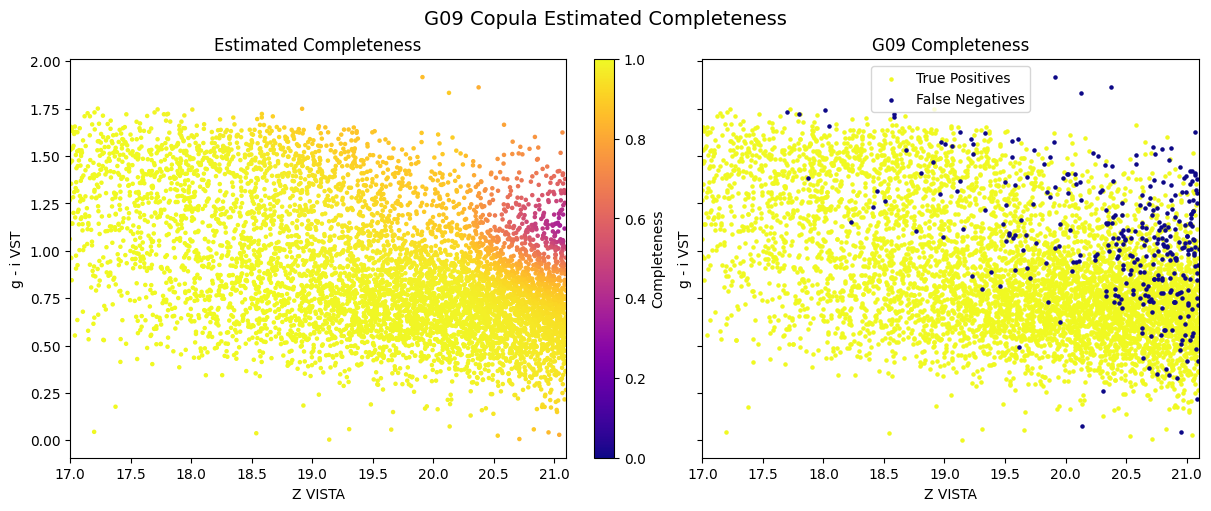

In [323]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True, constrained_layout=True)

sc0 = ax[0].scatter(-xy_all[:, 0] + 21.1, xy_all[:, 1], c=comp, s=5, cmap='plasma', vmin=0, vmax=1)
fig.colorbar(sc0, ax=ax[0], label='Completeness')
ax[0].set_title('Estimated Completeness')
ax[0].set_xlabel('Z VISTA')
ax[0].set_ylabel('g - i VST')
ax[0].set_xlim(17, 21.1)

tps = xy_all[xy_all_tp == 1]
fns = xy_all[xy_all_fn == 1]

ax[1].scatter(-tps[:, 0] + 21.1, tps[:, 1], s=5, color='#F0F921', label='True Positives')
ax[1].scatter(-fns[:, 0] + 21.1, fns[:, 1], s=5, color='#0D0887', label='False Negatives')
ax[1].set_title('G09 Completeness')
ax[1].set_xlabel('Z VISTA')
ax[1].set_ylabel('g - i VST')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].legend()
fig.suptitle("G09 Copula Estimated Completeness", fontsize=14)
plt.savefig("completeness_map.png", dpi=150)
plt.show()

In [324]:
print(1 - sum(comp) / len(comp))
print(pi_fp)

0.051185150018894454
0.05065077622706602


In [390]:
def x2u_empirical(x):
    """Empirical CDF transform: rank data and scale to [0,1]."""
    return rankdata(x) / (len(x) + 1)

def x2x_g09(xy):
    """
    Transform new dataset into the same space as g09 by applying the empirical CDF transform
    """
    x, y = xy[:, 0], xy[:, 1]
    u = x2u_empirical(x)
    v = x2u_empirical(y)
    x_inv_cdf = inverse_cdf_numerical(u, mag_all, lin_cdf(mag_all))
    y_inv_cdf = inverse_cdf_numerical(v, xr_gi, cdf_gi)
    return np.array([x_inv_cdf, y_inv_cdf]).T

In [325]:
sharks = pd.read_parquet('/Users/sp624AA/Downloads/group_finding_mocks/galaxies_shark.parquet')

In [326]:
for i in sharks.columns:
    print(i)

id_galaxy_sky
ra
dec
redshift_observed
redshift_cosmological
inclination
position_angle
mass_stellar_disk
mass_stellar_bulge
mass_stellar_total
mass_virial_hosthalo
mass_virial_subhalo
cnfw_subhalo
sfr_disk
sfr_burst
sfr_total
radius_disk_apparent
radius_bulge_apparent
radius_disk_instrinsic
id_group_sky
subvolume
vel_peculiar_x
vel_peculiar_y
vel_peculiar_z
vel_peculiar_radial
mag_FUV_GALEX
mag_NUV_GALEX
mag_u_SDSS
mag_g_SDSS
mag_r_SDSS
mag_i_SDSS
mag_z_SDSS
mag_u_VST
mag_g_VST
mag_r_VST
mag_i_VST
mag_Z_VISTA
mag_Y_VISTA
mag_J_VISTA
mag_H_VISTA
mag_K_VISTA
mag_W1_WISE
mag_I1_Spitzer
mag_I2_Spitzer
mag_W2_WISE
mag_I3_Spitzer
mag_I4_Spitzer
mag_W3_WISE
mag_W4_WISE
mag_M24_Spitzer
mag_M70_Spitzer
mag_P70_Herschel
mag_P100_Herschel
mag_P160_Herschel
mag_S250_Herschel
mag_S350_Herschel
mag_S450_JCMT
mag_S500_Herschel
mag_S850_JCMT
mag_Band_ionising_photons
mag_Band9_ALMA
mag_Band8_ALMA
mag_Band7_ALMA
mag_Band6_ALMA
mag_Band5_ALMA
mag_Band4_ALMA
mag_Band3_ALMA
mag_BandX_VLA
mag_BandC_VLA
ma

In [327]:
cols_to_keep = ['redshift_observed', 'mag_g_VST', 'mag_i_VST', 'mag_Z_VISTA', 'mass_stellar_total', 'id_fof', 'id_group_sky', 'mag_abs_Z_VISTA']

sharks = sharks[cols_to_keep]

In [328]:
sharks['g-i'] = sharks['mag_g_VST'] - sharks['mag_i_VST']

In [329]:
sel_sharks = (sharks['mag_Z_VISTA'] < 21.1) * (sharks['redshift_observed'] < 0.2) * (sharks['mass_stellar_total'] > 8)

In [330]:
wide_sharks = sharks[sel_sharks].reset_index(drop=True)

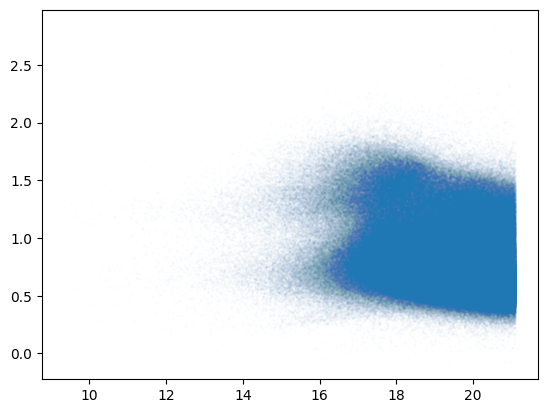

In [331]:
plt.scatter(wide_sharks['mag_Z_VISTA'], wide_sharks['g-i'], s=1, alpha=0.01)

In [332]:
xy_sharks = np.column_stack([-wide_sharks['mag_Z_VISTA'] + 21.1, wide_sharks['g-i']])

In [384]:
xy_sharks[0]

array([0.3908882 , 0.76423264], dtype=float32)

In [393]:
new_xy = x2x_g09(xy_sharks)

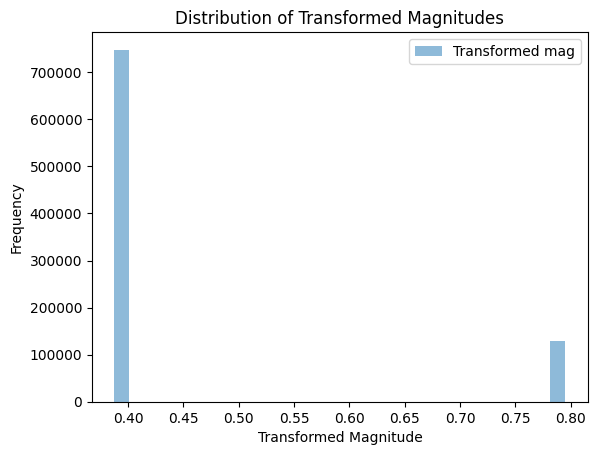

In [394]:
plt.hist(new_xy[:, 0], bins=30, alpha=0.5, label='Transformed mag')
plt.xlabel('Transformed Magnitude')
plt.ylabel('Frequency')
plt.title('Distribution of Transformed Magnitudes')
plt.legend()
plt.show()

In [334]:
comp_sharks = get_completeness(xy_sharks, cop_all, cop_fn, pi_fp)

In [335]:
# generate boolean array for a subsample of sharks..
subsample_sharks_inds = wide_sharks.sample(10000, random_state=42).index
subsample_sharks = wide_sharks.index.isin(subsample_sharks_inds)

In [336]:
subsample_sharks

array([False, False, False, ..., False, False, False], shape=(876593,))

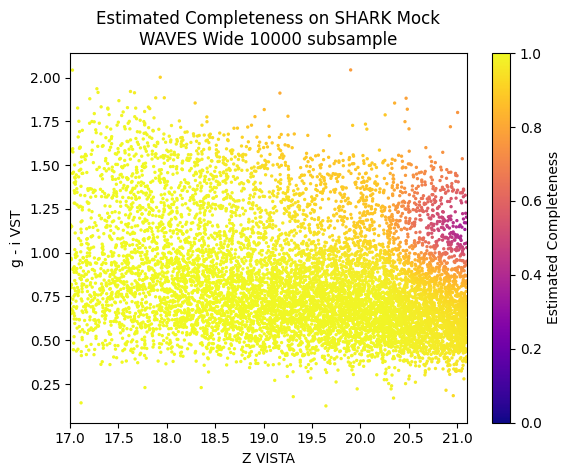

In [356]:
plt.scatter(wide_sharks['mag_Z_VISTA'][subsample_sharks], wide_sharks['g-i'][subsample_sharks], c=comp_sharks[subsample_sharks], s = 2, cmap='plasma', vmin=0, vmax=1)
plt.colorbar(label='Estimated Completeness')
plt.xlabel('Z VISTA')
plt.ylabel('g - i VST')
plt.xlim(17, 21.1)
plt.title(f'Estimated Completeness on SHARK Mock\nWAVES Wide 10000 subsample')
plt.savefig("completeness_map_shark.png", dpi=150)  

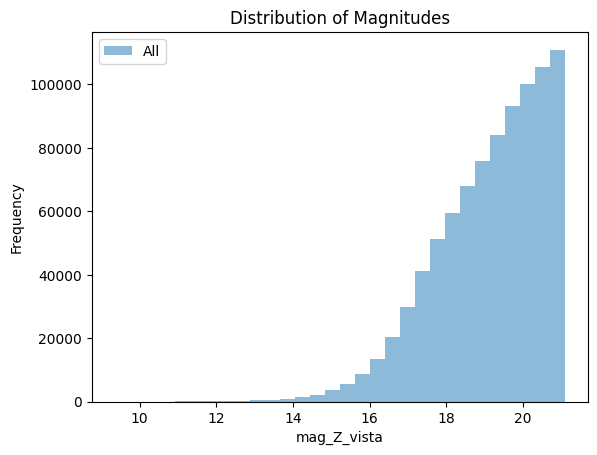

In [338]:
plt.hist(wide_sharks['mag_Z_VISTA'], bins=30, alpha=0.5, label='All')
plt.xlabel('mag_Z_vista')
plt.ylabel('Frequency')
plt.title('Distribution of Magnitudes')
plt.legend()
plt.show()

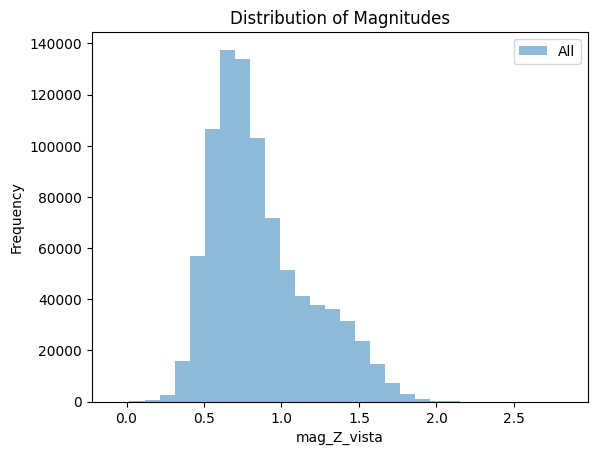

In [339]:
plt.hist(wide_sharks['g-i'], bins=30, alpha=0.5, label='All')
plt.xlabel('mag_Z_vista')
plt.ylabel('Frequency')
plt.title('Distribution of Magnitudes')
plt.legend()
plt.show()

In [340]:
sum(comp_sharks) / len(comp_sharks)

np.float64(0.9597837811827985)

In [341]:
wide_sharks['photoz_completeness'] = comp_sharks

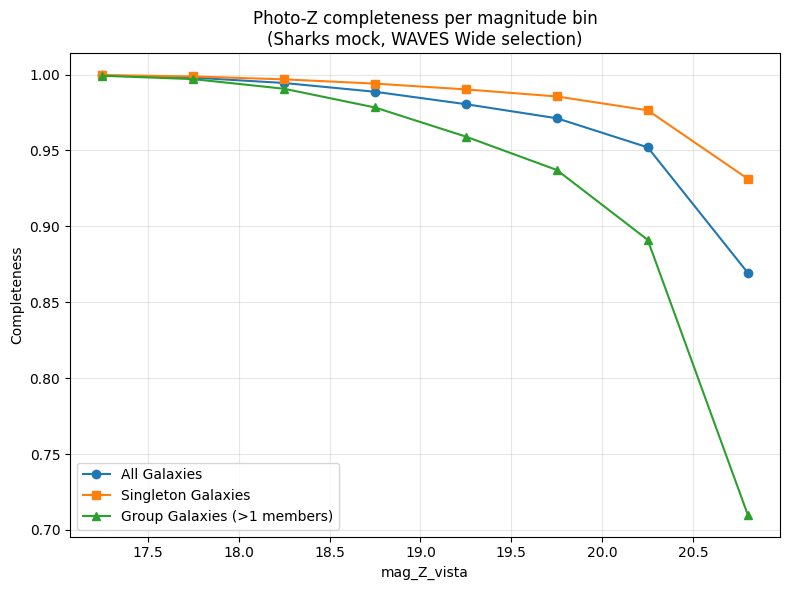

In [358]:
# --- 1. Magnitude bins ---
bins = np.array([17, 17.5,18, 18.5, 19, 19.5, 20, 20.5, 21.1])
bin_centers = 0.5 * (bins[:-1] + bins[1:])
wide_sharks['mag_bin'] = pd.cut(wide_sharks['mag_Z_VISTA'], bins=bins, include_lowest=True)

# --- 2. Group sizes ---
group_sizes = wide_sharks[wide_sharks['id_fof'] != -1].groupby('id_fof').size()
wide_sharks['group_size'] = wide_sharks['id_fof'].map(group_sizes)
wide_sharks.loc[wide_sharks['id_fof'] == -1, 'group_size'] = 1  # field = size 1

# Categories
wide_sharks['category'] = 'multi'
wide_sharks.loc[wide_sharks['group_size'] == 1, 'category'] = 'single'

# --- 3. Define estimator: sum(completeness) / N ---
def completeness_estimator(x):
    return x.sum() / x.count()

# Compute per bin
mean_all = wide_sharks.groupby('mag_bin')['photoz_completeness'].apply(completeness_estimator)

mean_single = wide_sharks[wide_sharks['category'] == 'single'] \
    .groupby('mag_bin')['photoz_completeness'].apply(completeness_estimator)

mean_multi = wide_sharks[wide_sharks['category'] == 'multi'] \
    .groupby('mag_bin')['photoz_completeness'].apply(completeness_estimator)

# --- 4. Plot ---
plt.figure(figsize=(8,6))

plt.plot(bin_centers, mean_all.values, marker='o', label='All Galaxies')
plt.plot(bin_centers, mean_single.values, marker='s', label='Singleton Galaxies')
plt.plot(bin_centers, mean_multi.values, marker='^', label='Group Galaxies (>1 members)')

plt.title('Photo-Z completeness per magnitude bin\n(Sharks mock, WAVES Wide selection)')
plt.xlabel('mag_Z_vista')
plt.ylabel('Completeness')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("completeness_vs_mag_shark.png", dpi=150)
plt.show()

In [343]:
# --- Group sizes ---
group_sizes = wide_sharks[wide_sharks['id_fof'] != -1].groupby('id_fof').size()
wide_sharks['group_size'] = wide_sharks['id_fof'].map(group_sizes)
wide_sharks.loc[wide_sharks['id_fof'] == -1, 'group_size'] = 1  # field = size 1

# Define masks
mask_single = wide_sharks['group_size'] == 1        # field + 1-member groups
mask_multi  = wide_sharks['group_size'] > 1         # real groups

# --- Completeness estimator: sum / N ---
def completeness(x):
    return x.sum() / x.count()

# --- Compute totals ---
comp_all    = completeness(wide_sharks['photoz_completeness'])
comp_single = completeness(wide_sharks.loc[mask_single, 'photoz_completeness'])
comp_multi  = completeness(wide_sharks.loc[mask_multi,  'photoz_completeness'])

print("All sample:", comp_all)
print("No groups (field + 1-member):", comp_single)
print("Groups (>1 members):", comp_multi)

All sample: 0.9597837811827696
No groups (field + 1-member): 0.9771593933431681
Groups (>1 members): 0.9278754841414446


In [344]:
# --- Group sizes ---
max_mag_lim = 20.8
wide_sharks_lim = wide_sharks[wide_sharks['mag_Z_VISTA'] < max_mag_lim].copy()

group_sizes = wide_sharks_lim[wide_sharks_lim['id_fof'] != -1].groupby('id_fof').size()
wide_sharks_lim['group_size'] = wide_sharks_lim['id_fof'].map(group_sizes)
wide_sharks_lim.loc[wide_sharks_lim['id_fof'] == -1, 'group_size'] = 1  # field = size 1

# Define masks
mask_single = wide_sharks_lim['group_size'] == 1        # field + 1-member groups
mask_multi  = wide_sharks_lim['group_size'] > 1         # real groups

# --- Completeness estimator: sum / N ---
def completeness(x):
    return x.sum() / x.count()

# --- Compute totals ---
comp_all    = completeness(wide_sharks_lim['photoz_completeness'])
comp_single = completeness(wide_sharks_lim.loc[mask_single, 'photoz_completeness'])
comp_multi  = completeness(wide_sharks_lim.loc[mask_multi,  'photoz_completeness'])

print("All sample:", comp_all)
print("No groups (field + 1-member):", comp_single)
print("Groups (>1 members):", comp_multi)

All sample: 0.9719009660073883
No groups (field + 1-member): 0.9844289528901121
Groups (>1 members): 0.9489345597765688


In [345]:
xy_all

array([[0.7951099 , 0.56453636],
       [1.7191889 , 0.64179847],
       [0.52012931, 0.43692769],
       ...,
       [0.27021929, 0.7649074 ],
       [0.17954566, 0.61746757],
       [0.38775802, 0.64506643]], shape=(6377, 2))

In [346]:
u_mag_all

array([0.28886065, 0.56475276, 0.19434074, ..., 0.10349644, 0.06937239,
       0.14680889], shape=(6377,))

Text(0.5, 1.0, 'Distribution of u_mag_all')

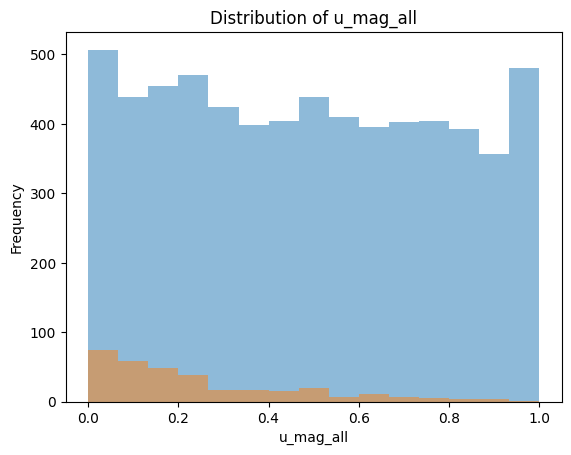

In [354]:
bins = np.linspace(0, 1, 16)
plt.hist(u_mag_all, bins=bins, alpha=0.5)
plt.hist(u_mag_all[xy_all_fn == 1], bins=bins, alpha=0.5)
plt.xlabel('u_mag_all')
plt.ylabel('Frequency')
plt.title('Distribution of u_mag_all')

Text(0.5, 1.0, 'Distribution of u_gi_all')

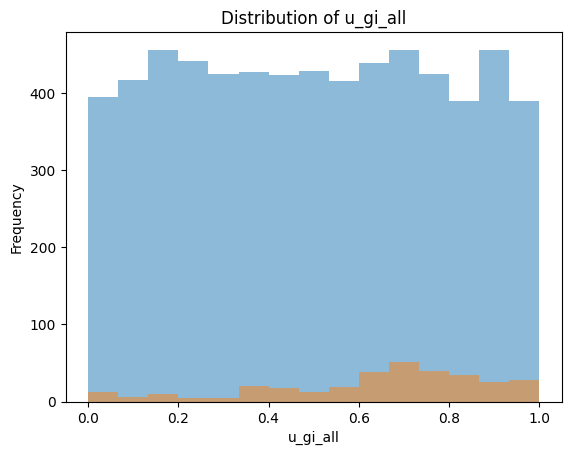

In [355]:
bins = np.linspace(0, 1, 16)
plt.hist(u_gi_all, bins=bins, alpha=0.5)
plt.hist(u_gi_all[xy_all_fn == 1], bins=bins, alpha=0.5)
plt.xlabel('u_gi_all')
plt.ylabel('Frequency')
plt.title('Distribution of u_gi_all')

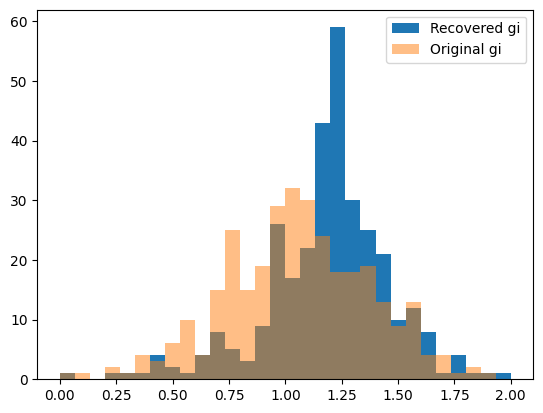

In [372]:
bins = np.linspace(0, 2, 31)
plt.hist(u_to_gi_fn(u_gi_all[xy_all_fn == 1]), bins = bins)
plt.hist(xy_all[xy_all_fn == 1][:, 1], bins=bins, alpha=0.5)
plt.legend(['Recovered gi', 'Original gi'])

(array([ 6.,  6.,  8.,  6.,  7., 13., 11.,  6.,  8.,  6., 12., 25., 17.,
        21.,  9.]),
 array([0.        , 0.06666667, 0.13333333, 0.2       , 0.26666667,
        0.33333333, 0.4       , 0.46666667, 0.53333333, 0.6       ,
        0.66666667, 0.73333333, 0.8       , 0.86666667, 0.93333333,
        1.        ]),
 <BarContainer object of 15 artists>)

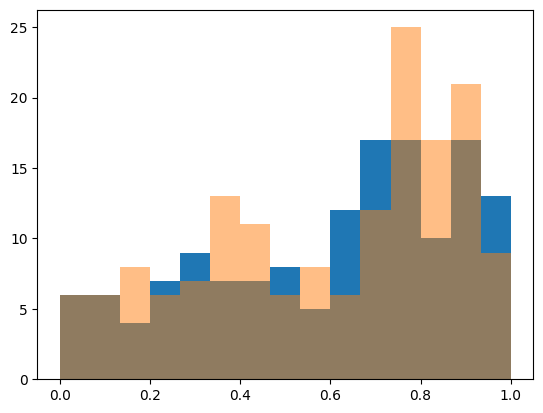

In [377]:
bins = np.linspace(0, 1, 16)
plt.hist(density_real_gi_fn(u_to_gi_fn(u_gi_all[xy_all_fn == 1])), bins = bins)
plt.hist(density_real_gi_fn(xy_all[xy_all_fn == 1][:, 1]), bins=bins, alpha=0.5)